# Recordar instalar librería

In [ ]:
#!pip install darts

# Cargar librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import NaiveDrift, NaiveSeasonal, ExponentialSmoothing
from darts.metrics import mape
from darts.datasets import AirPassengersDataset

# Cargar base de datos

<Axes: xlabel='Month'>

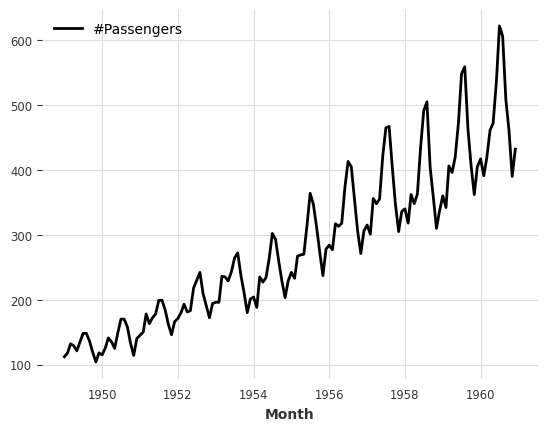

In [58]:
series = AirPassengersDataset().load()
series.plot()

# Crear modelos

## NaiveDrift
Es una extrapolación lineal súper simple: traza una línea entre el primer y el último valor de tu serie de entrenamiento y la prolonga hacia el futuro. Es decir, usa la pendiente promedio observada entre el inicio y el final (“drift”) y la extiende. Datos rápido sobre él:
* Como baseline rápido para comparar modelos más complejos.
* En series con tendencia aproximadamente lineal y sin estacionalidad marcada.
* Sensible a outliers en los extremos (inicio o fin).
* No modela estacionalidad ni cambios de tendencia; es determinista (sin incertidumbre).

In [59]:
naive_drift_model = NaiveDrift()

## NaiveSeasonal
Es un modelo muy simple que repite los valores del pasado reciente, asumiendo que el comportamiento se repite cada cierto período. Usadas para series claramente estacionales, pero no detecta tendencia ni cambios: solo repite ciclos pasados, y requiere conocer o estimar el período estacional (K).

In [60]:
naive_seasonal_model = NaiveSeasonal()

## ExponentialSmoothing
Este modelo aplica una media móvil exponencial, donde los valores más recientes tienen más peso. Se usan en series con tendencia y estacionalidad estable, cuando quieres algo más flexible pero aún interpretable y muy útil para datos económicos, de ventas o meteorológicos. Pero supone que la tendencia y la estacionalidad son suaves y regulares y no maneja bien cambios abruptos o shocks externos.

In [61]:
exp_smooth_model = ExponentialSmoothing()

In [62]:
models = [naive_drift_model, naive_seasonal_model, exp_smooth_model]

# Entrenamiento y validación

In [63]:
#Separamos la serie en un conjunto de entrenamiento y otro de validación (test), respetando el orden temporal
train, val = series.split_before(pd.Timestamp('1960-01-01'))
forecast_horizon = 12#número de periodos a predecir

for model in models:#son tres modelos, ajustamos un bucle para no hacer repetitivo el codigo
    model.fit(train)
    forecast = model.predict(forecast_horizon)#Indica que cada modelo hará el número de pronóstico a forecast_horizon hacia adelante
    err = mape(val[:forecast_horizon], forecast)#Calcula el MAPE 
    #Este MAPE (Mean Absolute Percentage Error) comparando las 12 primeras observaciones reales (val) contra las 12 predicciones (forecast).
    print(f"MAPE Error para {model}: {err}")#Muestra el error de cada modelo, para poder compararlos.

MAPE Error para NaiveDrift(): 12.417957002111175
MAPE Error para NaiveSeasonal(): 14.251338486772207
MAPE Error para ExponentialSmoothing(): 2.802733796627242


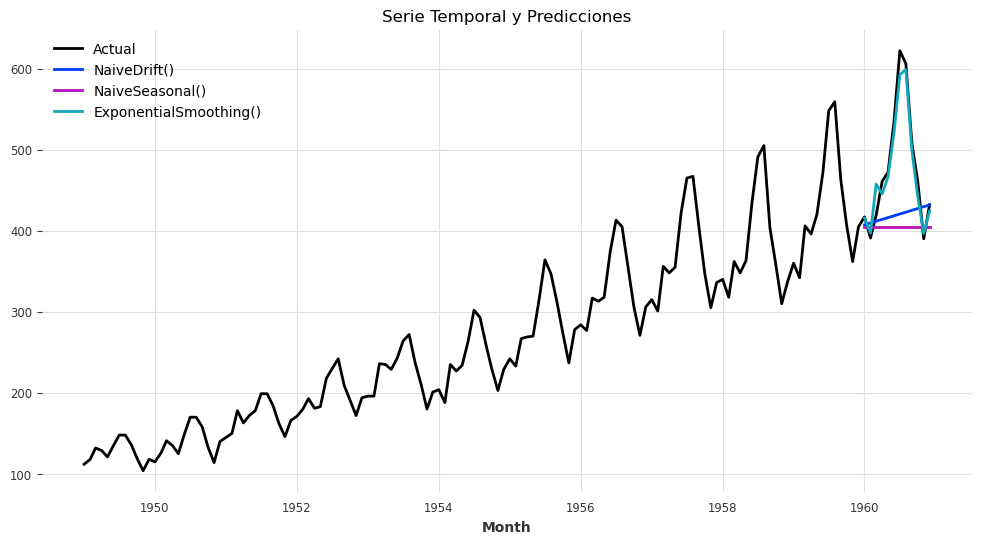

In [64]:
plt.figure(figsize=(12, 6))
series.plot(label="Actual", lw=2)

for model in models:
    model.fit(train)
    forecast = model.predict(forecast_horizon)
    forecast.plot(label=str(model), lw=2)

plt.title("Serie Temporal y Predicciones")
plt.legend()
plt.grid(True)
plt.show()

# TAREA PROPUESTA
TRATANDO DE MODELAR PERO CONTROLANDO VARIANZA PREVIAMENTE, AUMENTA EL ERROR, CASI UN PUNTO

In [ ]:
from scipy.stats import boxcox
from scipy.special import inv_boxcox 

In [ ]:
#PRIMERO, ESTABILIZAR VARIANZA
values_T = train.values()#Numpy array sobre datos de entrenamiento, solamente
#Extraer fechas y valores usando Numpy
time_index_T = train.time_index#índice temporal
# Crear DataFrame de pandas, para respetar el proceso del profe. 
values_T = pd.DataFrame(values_T, index=time_index_T, columns=['valores'])#se crea un DF llamado como en el código deprecado

boxcox_values_T, lambda_value_T = boxcox(values_T['valores'].to_numpy())#.boxcox exige un arreglo 1D. De ahí que involucre la columna
print(f'Lambda: {lambda_value_T}')#Valor de parámetro, sigue siendo 0.1289

Lambda: 0.12887091770978606


In [67]:
boxcox_values_T = pd.DataFrame(boxcox_values_T, index=time_index_T, columns=['valores_BOX-COX'])

In [68]:
series_bc = TimeSeries.from_dataframe(boxcox_values_T, value_cols='valores_BOX-COX')

In [ ]:
for model in models:#son tres modelos, ajustamos un bucle para no hacer repetitivo el codigo
    model.fit(series_bc)
    forecast = model.predict(forecast_horizon)#Indica que cada modelo hará el número de pronóstico a forecast_horizon hacia adelante
    #Volver a escala original (clave para que el MAPE tenga sentido)
    fc_orig_vals = inv_boxcox(forecast.values().flatten(), lambda_value_T)#Aplicando el lambda de train
    fc_orig = TimeSeries.from_times_and_values(forecast.time_index, fc_orig_vals)
    # Alinear con los reales (escala original)
    y_val = val[:forecast_horizon]# 12 primeros puntos de VALIDACIÓN
    err = mape(y_val, fc_orig)#Calcula el MAPE 
    #Este MAPE (Mean Absolute Percentage Error) comparando las 12 primeras observaciones reales (val) contra las 12 predicciones (forecast).
    print(f"MAPE Error para {model}: {err}")#Muestra el error de cada modelo, para poder compararlos.

MAPE Error para NaiveDrift(): 11.893334197178135
MAPE Error para NaiveSeasonal(): 14.251338486772177
MAPE Error para ExponentialSmoothing(): 3.7509266075127154


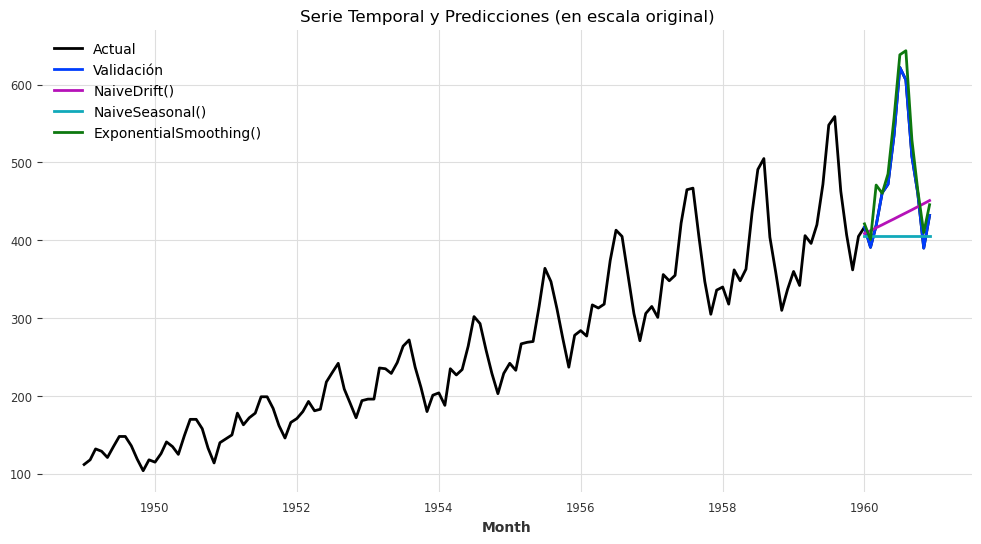

In [ ]:
plt.figure(figsize=(12, 6))
# HISTÓRICO en escala original
series.plot(label="Actual", lw=2)
# (opcional) mostrar también el tramo de validación para ver la comparación
val.plot(label="Validación", lw=2)

for model in models:
    # Entrenas en la serie transformada (Box-Cox) de TRAIN
    model.fit(series_bc)#Es el TRAIN ya en Box-Cox
    # Prediccion 12 pasos ADELANTE
    forecast= model.predict(forecast_horizon)#forecast en escala Box-Cox
    # Deshacer a escala original ANTES de evaluar y plotear
    fc_orig_vals = inv_boxcox(forecast.values().flatten(), lambda_value_T)
    fc_orig = TimeSeries.from_times_and_values(forecast.time_index, fc_orig_vals)
    # Plot en la MISMA escala que 'series'
    fc_orig.plot(label=str(model), lw=2)

plt.title("Serie Temporal y Predicciones (en escala original)")
plt.legend()
plt.grid(True)
plt.show()